In [ ]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# loading the dataset
df = pd.read_csv('Online Retail.csv', encoding='latin-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [6]:
# fixing column name issue
df.columns = df.columns.str.replace('ï»¿', '')

# removing rows where customer id is missing
df = df.dropna(subset=['CustomerID'])

# removing cancelled orders
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# keeping only valid quantities and prices
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

# converting data types
df['CustomerID'] = df['CustomerID'].astype(int)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# adding total price column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

df.shape

C:\Users\harsh\AppData\Local\Temp\ipykernel_14676\1722279330.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


(397884, 9)

In [7]:
# setting reference date for recency calculation
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# calculating rfm values for each customer
rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [8]:
# setting reference date for recency calculation
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# calculating rfm values for each customer
rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [9]:
# scoring customers from 1 to 4
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1,2,3,4])

# combining scores
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# segmenting customers
def segment_customer(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])
    if r >= 3 and f >= 3 and m >= 3:
        return 'Champions'
    elif r >= 3 and f >= 2:
        return 'Loyal Customers'
    elif r >= 3 and f <= 2:
        return 'Recent Customers'
    elif r == 2 and f >= 2:
        return 'At Risk'
    else:
        return 'Lost Customers'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)
rfm['Segment'].value_counts()

Segment
Lost Customers      1391
Champions           1319
At Risk              759
Loyal Customers      610
Recent Customers     259
Name: count, dtype: int64

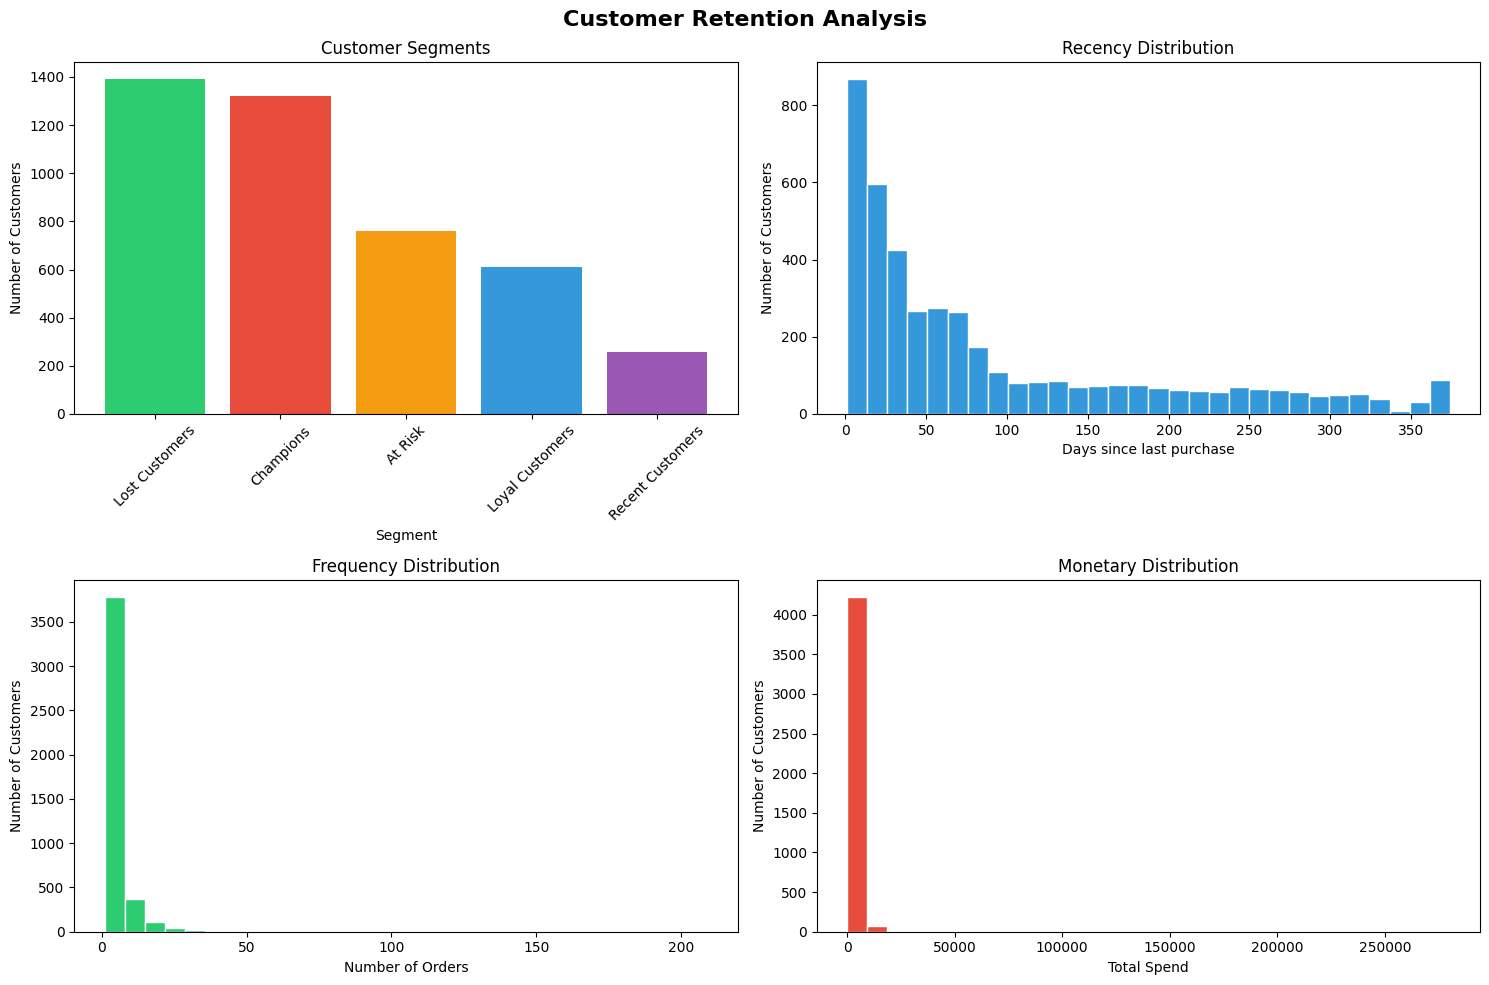

In [10]:
# visualizing the results
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Customer Retention Analysis', fontsize=16, fontweight='bold')

segment_counts = rfm['Segment'].value_counts()
axes[0,0].bar(segment_counts.index, segment_counts.values,
              color=['#2ecc71','#e74c3c','#f39c12','#3498db','#9b59b6'])
axes[0,0].set_title('Customer Segments')
axes[0,0].set_xlabel('Segment')
axes[0,0].set_ylabel('Number of Customers')
axes[0,0].tick_params(axis='x', rotation=45)

axes[0,1].hist(rfm['Recency'], bins=30, color='#3498db', edgecolor='white')
axes[0,1].set_title('Recency Distribution')
axes[0,1].set_xlabel('Days since last purchase')
axes[0,1].set_ylabel('Number of Customers')

axes[1,0].hist(rfm['Frequency'], bins=30, color='#2ecc71', edgecolor='white')
axes[1,0].set_title('Frequency Distribution')
axes[1,0].set_xlabel('Number of Orders')
axes[1,0].set_ylabel('Number of Customers')

axes[1,1].hist(rfm['Monetary'], bins=30, color='#e74c3c', edgecolor='white')
axes[1,1].set_title('Monetary Distribution')
axes[1,1].set_xlabel('Total Spend')
axes[1,1].set_ylabel('Number of Customers')

plt.tight_layout()
plt.savefig('customer_retention_charts.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# final summary
total_customers = len(rfm)
champions = len(rfm[rfm['Segment'] == 'Champions'])
lost = len(rfm[rfm['Segment'] == 'Lost Customers'])
at_risk = len(rfm[rfm['Segment'] == 'At Risk'])

print(f"total customers: {total_customers}")
print(f"champions: {champions} ({champions/total_customers*100:.1f}%)")
print(f"lost customers: {lost} ({lost/total_customers*100:.1f}%)")
print(f"at risk: {at_risk} ({at_risk/total_customers*100:.1f}%)")
print(f"average order value: ${rfm['Monetary'].mean():.2f}")
print(f"average frequency: {rfm['Frequency'].mean():.1f} orders")
print(f"average recency: {rfm['Recency'].mean():.0f} days")

total customers: 4338
champions: 1319 (30.4%)
lost customers: 1391 (32.1%)
at risk: 759 (17.5%)
average order value: $2054.27
average frequency: 4.3 orders
average recency: 93 days
